In [1]:
import torch
from torch import utils
import numpy as np
import torchvision as tv
from torchvision.models import vgg16 as VGG
from torchvision.datasets import Imagenette
import torchvision.transforms as tfs
import torch.nn as nn
from torchsummary import summary
from sklearn.model_selection import train_test_split
from pathlib import Path
import pickle
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import importlib
import extract
from extract import VGG16FeatureExtractor as features
import fmppmi as ppmi
importlib.reload(extract)
importlib.reload(ppmi)

<module 'fmppmi' from 'C:\\Users\\Alex Merino\\Documents\\research_MI\\fmppmi.py'>

In [3]:
# Unpickles the pickled files
def get_maps(path):
    image = None

    # UNPICKLE
    with open (path, 'rb') as f:
        image = pickle.load(f)

    return image



def stack_filters(fms):
    '''
        
        Restacks feature maps by switching indeces of lists (essentially)
    
        Parameters
        ----------
            fms: array-like
                The list of feature maps from a group of inputs of one layer of a convolution

        Returns
        ------
            stack: array_like
                A 2-D list which has all feature maps from one filter in a convolutional layer as the first-dimension.
                The second dimension returns the feature map

                stack[0] -> Returns the list of feature maps from filter_0
                stack[0][0] -> Returns the feature map of image_0 from filter_0
    '''

    # Get amount of filters in layer and loop through
    # Go through each input image and grab the current filter
    return [[x[0][i] for x in fms] for i in range(fms[0][0].size()[0])]



def get_pixel_loc(feature, x, y):
    '''
        Grabs a pixel location from a list of feature maps

        Parameters
        ----------

        Returns
        -------
            stream: torch.tensor()
                The list of pixels in the form of a torch tensor
    '''

    
    loc = []

    # Go through each feature map in list
    return torch.tensor([image[x][y] for image in feature])



def one_for_all(feat1, feat2, f1x, f1y):
    '''
        Function that creates a pixel stream from a list of feature maps
        and calculates the Mutual Information between that and each pixel
        stream in the second list of feature maps

        Parameters
        ----------
            feat1: array_like
                The list of feature maps from a filter in a convolutional
                layer
            feat2: array_like
                The list of feature maps from a different filter in the
                same convolutional layer as feat1 
            f1x: int
                The x location of the pixel stream being calculated in
                feat1
            f1y: int
                The y location of the pixel stream being calculated in
                feat1
                
        Returns
        -------
            total: float
                The total calculated mutual information between pixel location
                in list 1 and all pixel locations in list 2 
    '''
    # Get pixel stream from filter 1
    f1 = get_pixel_loc(feat1, f1x, f1y)
    total = 0

    # for x pixel in filter
    for x in range(feat2[0].size()[0]):
        # for y pixel in filter
        for y in range(feat2[0].size()[0]):
            # Get pixel stream from (x,y) in filter 2
            f2 = get_pixel_loc(feat2, x, y)
            # Calculate MI between streams of pixels
            total += mi.streammi(f1, f2)
    # Return total MI
    return total

In [4]:
from mpl_toolkits.axes_grid1 import ImageGrid
def plot_two_filters(f1, f2):
    '''
        Parameters
        ----------
            f1: array-like
                The list of feature maps from one filter
                
            f2: array-like
                The list of feature maps from another filter

        Returns
        -------
            A plot display of all maps
    '''
    fig = plt.figure(figsize=(20, 20))
    
    
    grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                     nrows_ncols=(2,len(f1)),
                     axes_pad=0.25,
                     share_all=True,
                     cbar_location="right",
                     cbar_mode="single",
                     cbar_size="7%",
                     cbar_pad=0.15,
                     )
    
    for i, ax in enumerate(grid):
        if i < 11:
            im = ax.imshow(f1[i])
        else:    
            im = ax.imshow(f2[i-11])
       
    plt.show()

In [5]:
# Path of folder
folder = glob.glob("./feature_maps/test1/*")

# Get a list of input images
inputs = [get_maps(x) for x in folder]

In [6]:
# 1. For each layer in the model
# 2. Go through each image and get the feature maps  
# 3. Restack the feature maps and add to big list
#      3              2                        1   
sep = [stack_filters([fm[i] for fm in inputs]) for i in range(len(inputs[0])-1, -1, -1)]

In [7]:
print("Convolutional Layers in VGG model:", len(sep))
print("Number of filters in current layer:", len(sep[0]))
print("Number of inputs given:", len(sep[0][0]))
print("Size of filter for the current layer:", sep[0][0][0].size())

Convolutional Layers in VGG model: 13
Number of filters in current layer: 512
Number of inputs given: 11
Size of filter for the current layer: torch.Size([14, 14])


In [8]:
# We want to only focus on the last layer atm
last_layer = sep[0]

In [31]:
feature1 = last_layer[0]
feature2 = last_layer[1]

feature3 = sep[-1][0]
feature4 = sep[-1][1]

feat5 = sep[5][0]
feat6 = sep[5][1]

In [33]:
import streammi as mi
importlib.reload(mi)

<module 'streammi' from 'C:\\Users\\Alex Merino\\Documents\\research_MI\\streammi.py'>

In [34]:
f1 = get_pixel_loc(feature1, 0,0)
f2 = get_pixel_loc(feature2, 0,0)
f3 = get_pixel_loc(feature3, 0,0)
f4 = get_pixel_loc(feature4, 0,0)


In [49]:
one_for_all(feature1, feature2, 0, 0)

6.369592914791085

In [50]:
one_for_all(feature1, feature2, 1, 1)

1.8877031768636872

In [39]:
# get all mutual information for one filter to another
allmi = [[one_for_all(feature1, feature2, x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]

1359.4946558792985


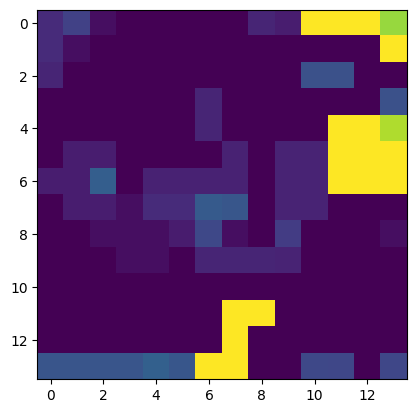

In [40]:
print(np.sum(allmi))
plt.imshow(allmi)

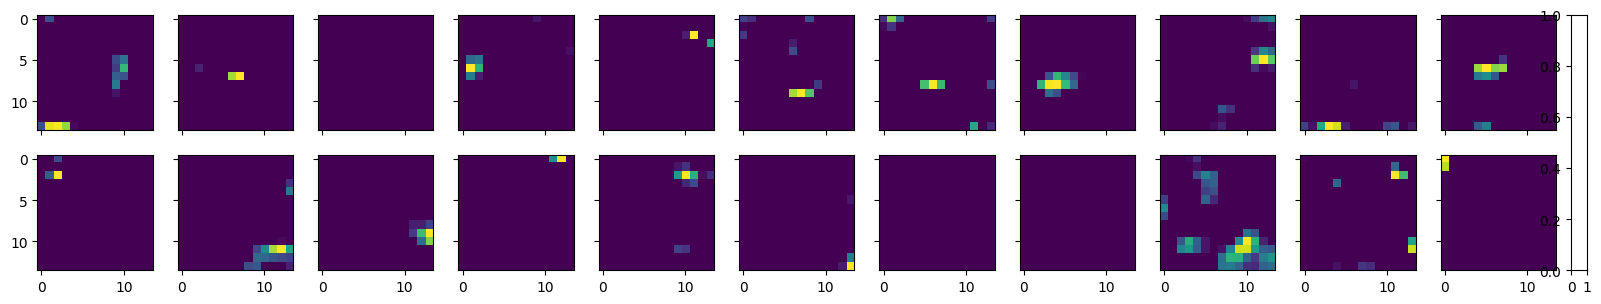

In [41]:
plot_two_filters(feature1, feature2)

In [56]:
mis2 = np.zeros((feat5[0].size()[0],feat5[0].size()[0]))

for x in range(feat5[0].size()[0]):
        for y in range(feat5[0].size()[0]):
            mis2[x][y] = one_for_all(feat5, feat6, x, y)

136925.08705892763


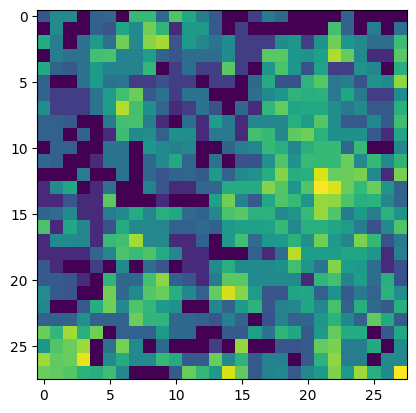

In [60]:
print(np.sum(mis2))
plt.imshow(mis2)

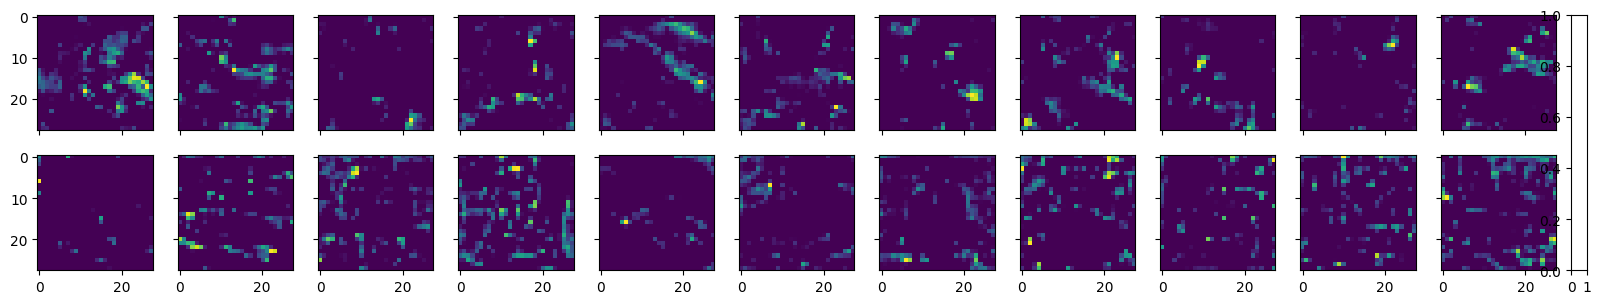

In [58]:
plot_two_filters(feat5, feat6)

In [24]:
# Get size of layer
size = len(last_layer[0][0])
# path name
base = "./filter_mi/filter_"

for f in range(len(last_layer)-1):  # Don't need final filter here
    # file name
    file_name = base + str(f) + ".txt"

    # Check if the file exists
    if os.path.exists(file_name):
        continue

    # create file and write to it    
    with open (file_name, "w") as file:
        
        for o in range(f+1, len(last_layer)):  # Don't need current filter here, but need final filter
            # Sum of MI
            total = 0

            # go through each pixel in first filter, f
            for x in range(size):
                for y in range(size):
                    # Calculate MI with every pixel in other filter, o
                   total += one_for_all(last_layer[f], last_layer[o], x, y)
            # Write total to file
            file.write(f"Filter {o}: {total:.5f}\n")
        file.close()  # Close file

KeyboardInterrupt: 

In [73]:
with open ('./filter_mi/filter_0.txt', 'r') as file:
    vals = [float(x.split(": ")[-1].strip("\n")) for x in file]

In [54]:
copy = sorted(vals)

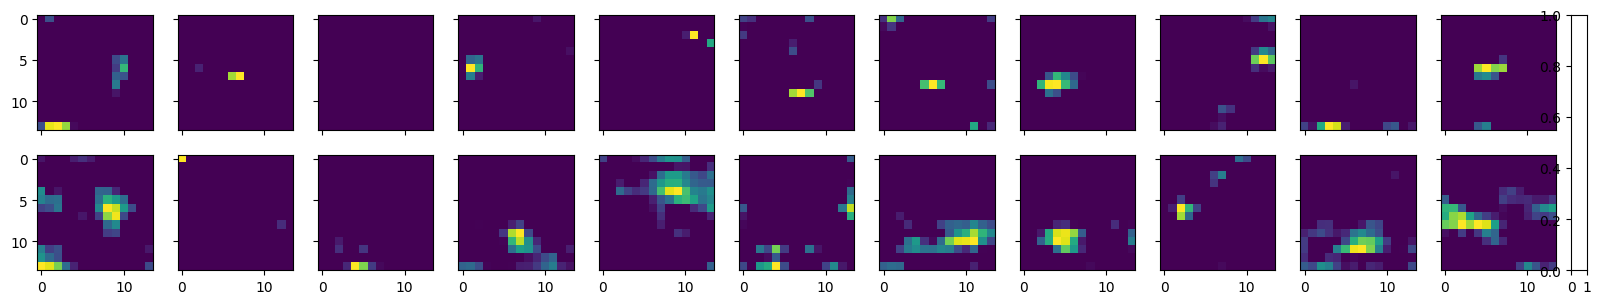

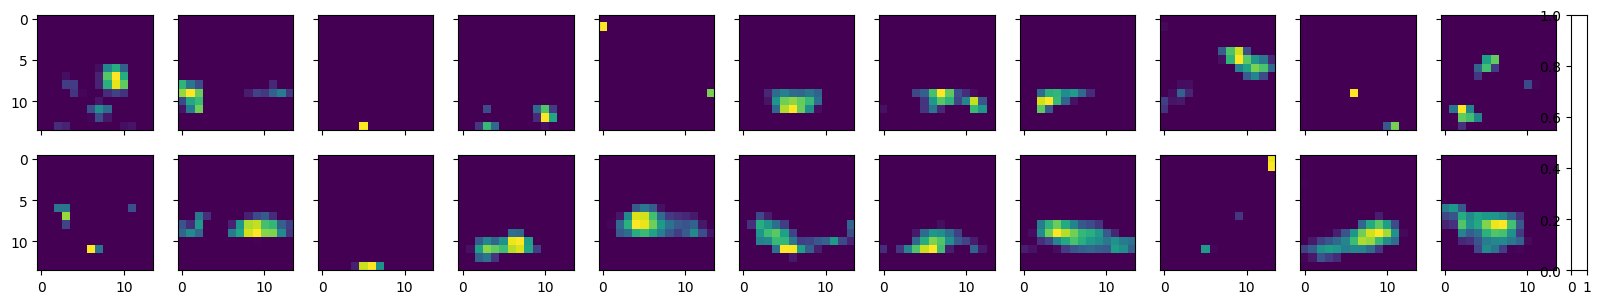

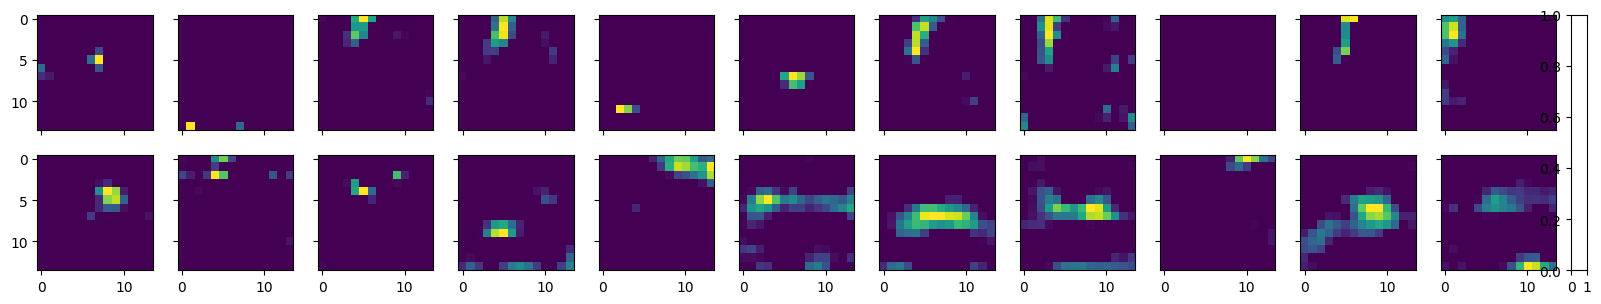

In [60]:
plot_two_filters(last_layer[0], last_layer[vals.index(copy[-1])])
plot_two_filters(last_layer[vals.index(copy[-2])], last_layer[vals.index(copy[-3])])
plot_two_filters(last_layer[vals.index(copy[-4])], last_layer[vals.index(copy[-5])])

In [63]:
one_two = [[one_for_all(last_layer[vals.index(copy[-1])], last_layer[vals.index(copy[-2])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
one_three = [[one_for_all(last_layer[vals.index(copy[-1])], last_layer[vals.index(copy[-3])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
one_four = [[one_for_all(last_layer[vals.index(copy[-1])], last_layer[vals.index(copy[-4])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
one_five = [[one_for_all(last_layer[vals.index(copy[-1])], last_layer[vals.index(copy[-5])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
two_three = [[one_for_all(last_layer[vals.index(copy[-2])], last_layer[vals.index(copy[-3])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
two_four = [[one_for_all(last_layer[vals.index(copy[-2])], last_layer[vals.index(copy[-4])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
two_five = [[one_for_all(last_layer[vals.index(copy[-2])], last_layer[vals.index(copy[-5])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
three_four = [[one_for_all(last_layer[vals.index(copy[-3])], last_layer[vals.index(copy[-4])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
three_five = [[one_for_all(last_layer[vals.index(copy[-3])], last_layer[vals.index(copy[-5])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]
four_five = [[one_for_all(last_layer[vals.index(copy[-4])], last_layer[vals.index(copy[-5])], x, y) for y in range(feature1[0].size()[0])] for x in range(feature1[0].size()[0])]

In [79]:
for i in range(1, 6):
    print(f"Filter {vals.index(copy[-1 * i])}: {copy[-1 * i]}")
    
difs = [one_two, one_three, one_four, one_five, two_three, two_four, two_five, three_four, three_five, four_five]
for g in difs:
    print(np.sum(g))

Filter 193: 4480.7556
Filter 322: 4287.1266
Filter 99: 4194.98267
Filter 336: 4173.15624
Filter 467: 4151.62928
4028.307204476057
6476.476781214153
3849.380583630808
9511.77344490743
2488.359748325668
1734.7847515519338
4163.936587974146
2712.0410602640613
7114.024300142118
4475.987974237266


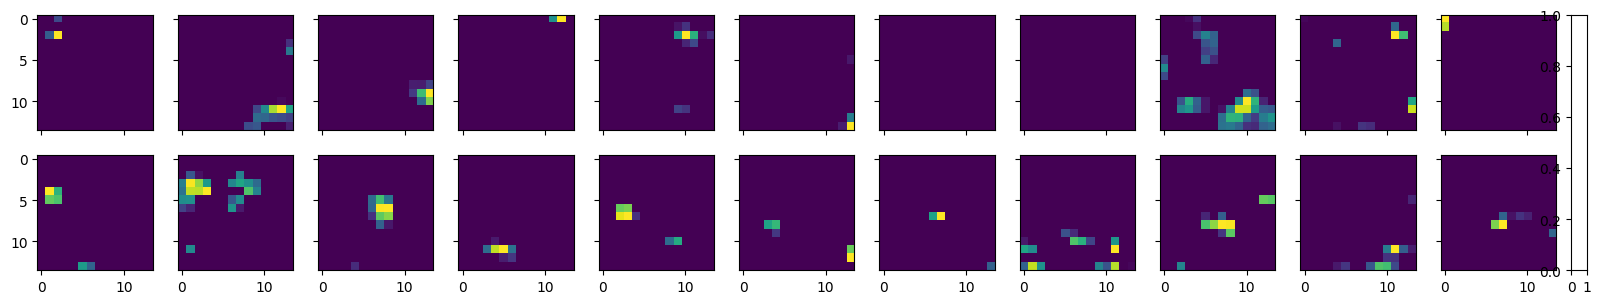

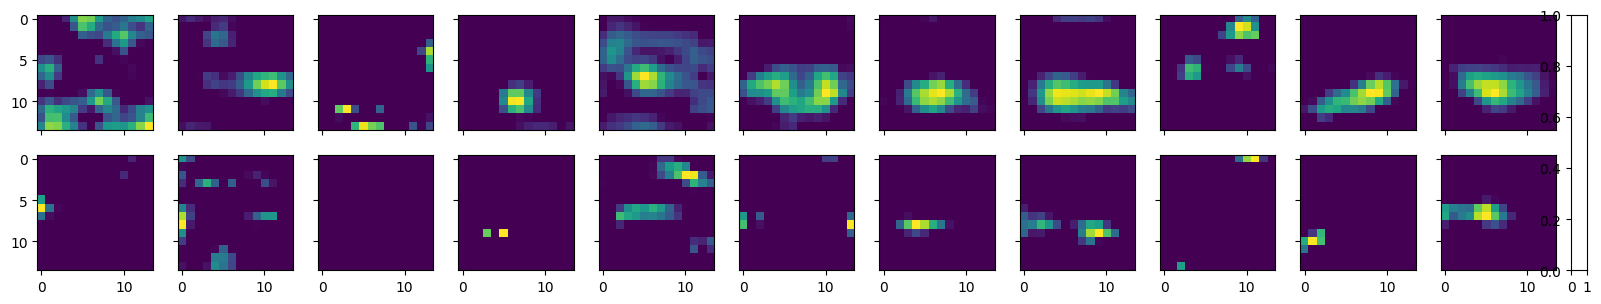

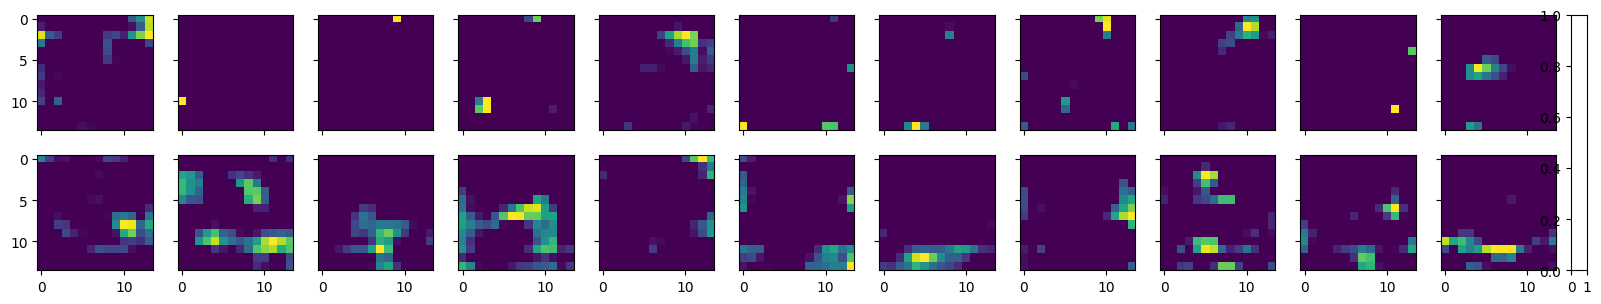

In [80]:
with open ('./filter_mi/filter_1.txt', 'r') as file:
    vals2 = [float(x.split(": ")[-1].strip("\n")) for x in file]
    
copy2 = sorted(vals2)

plot_two_filters(last_layer[1], last_layer[vals2.index(copy2[-1])])
plot_two_filters(last_layer[vals2.index(copy2[-2])], last_layer[vals2.index(copy2[-3])])
plot_two_filters(last_layer[vals2.index(copy2[-4])], last_layer[vals2.index(copy2[-5])])

In [82]:
for i in range(1, 6):
    print(f"Filter {vals2.index(copy2[-1 * i])}: {copy2[-1 * i]}")
   

Filter 495: 5762.87111
Filter 100: 5485.80855
Filter 448: 5401.86316
Filter 329: 4820.6855
Filter 462: 4815.10536


In [76]:
vals.index(copy[-1])

193

In [67]:
model_path = './models/full.pth'

state_dict = torch.load(model_path, weights_only=True)
state_dictm1 = torch.load(model_path, weights_only=True)
state_dictm2 = torch.load(model_path, weights_only=True)
state_dictm3 = torch.load(model_path, weights_only=True)
state_dictm4 = torch.load(model_path, weights_only=True)
state_dictm5 = torch.load(model_path, weights_only=True)

In [47]:
for f in state_dict:
    if 'weight' in f:
        print(f)

features.0.weight
features.2.weight
features.5.weight
features.7.weight
features.10.weight
features.12.weight
features.14.weight
features.17.weight
features.19.weight
features.21.weight
features.24.weight
features.26.weight
features.28.weight
classifier.0.weight
classifier.3.weight
classifier.6.weight


16 Layers for vgg 16, makes sense

3 of them are flat layers (bro i forgor the name) and the other 13 are the convolutional layers, which we have in code above, so if we want to modify the last conv. layer we need *features.28.weight*

So there are 512 filters in this layer, same amount as the feature maps we created above, not sure why dim=1 (second dimension) is 512 though

The [3,3] at the end are the size of the filter which makes sense

In [68]:
last_filters = state_dict['features.28.weight']
last_filters.size()

torch.Size([512, 512, 3, 3])

In [69]:
base = last_filters[0]
highs = [467,336,99,322,193]

change = [(state_dictm1, './models/min1.pth'), (state_dictm2, './models/min2.pth'),(state_dictm3, './models/min3.pth'),(state_dictm4, './models/min4.pth'),(state_dictm5, './models/min5.pth')]

In [70]:
for j, (model, path) in zip(range(0, len(highs)+1), change):
    #print(j, model, path)
    for i in range(0, j):
        model['features.28.weight'][highs[i]] = torch.zeros(last_filters[i].size())
    print(f'Saving to {path}')
    torch.save(model, path)
        # last_filters[i] = torch.zeros(last_filters[i].size())

Saving to ./models/min1.pth
Saving to ./models/min2.pth
Saving to ./models/min.pth
Saving to ./models/min4.pth
Saving to ./models/min5.pth


In [89]:
def test(model, loader):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            outputs = model(data)
            
            # Calculate loss
            loss = crit(outputs, target)
            val_loss += loss.item()
            pred = outputs.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    
    avg_loss = val_loss / len(loader)
    accuracy = correct / total
    print(f'Validation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')
    return avg_loss, accuracy

In [104]:
dataset = torch.utils.data(".\\data\\imagenette2\\val\\n01440764")  

data_loader = torch.utils.data.DataLoader(dataset,
                                          batch_size=4,
                                          shuffle=True, transform=tfs.ToTensor())
#len(data_loader)
features, labels = next(iter(data_loader))

TypeError: 'module' object is not callable

In [92]:
paths = ['./models/min1.pth','./models/min2.pth','./models/min3.pth','./models/min4.pth','./models/min5.pth']

for p in paths:

    cur_model = VGG()
    cur_model.load_state_dict(torch.load(p, weights_only=True))
    loss, acc = test(cur_model, data_loader)
    print(f"Loss: {loss}\t\t\tAccuracy: {acc*100:0.3f}")

ValueError: not enough values to unpack (expected 2, got 1)